# EE6024 Assignment 3 – Heart Disease Classification Report

---
## 1. Summary

This report develops and evaluates machine learning classifiers for early-stage heart disease detection using the IEEE DataPort dataset of 1190 patient records with 11 clinical features. After removal of 272 exact duplicate rows and investigation of missing data, class-conditional median imputation was applied to cholesterol: 29.9% of heart disease patients had missing cholesterol versus only 4.9% of normal patients, making global imputation inappropriate. Feature selection used permutation importance alongside a correlation heatmap; cross-validated subset comparison confirmed no feature removal was reliably beneficial, and all 11 features are retained. Three classifiers were compared in a patient-independent 80/20 stratified train/test split. The **Gradient Boosting Classifier** achieved the highest ROC-AUC (0.947), making it the preferred model for a screening context where the decision threshold may be adjusted to clinical requirements.


---
## 2. Imports and Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, recall_score, ConfusionMatrixDisplay
)
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries loaded.')


Libraries loaded.


---
## 3. Data Loading and Inspection


In [2]:
df = pd.read_csv('heart_disease_data.csv')
print(f'Raw shape: {df.shape}')
display(df.head())


Raw shape: (1190, 12)


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [4]:
display(df.describe().round(2))


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00,1190.00
mean,53.72,0.76,3.23,132.15,210.36,0.21,0.70,139.73,0.39,0.92,1.62,0.53
std,9.36,0.42,0.94,18.37,101.42,0.41,0.87,25.52,0.49,1.09,0.61,0.50
min,28.00,0.00,1.00,0.00,0.00,0.00,0.00,60.00,0.00,-2.60,0.00,0.00
25%,47.00,1.00,3.00,120.00,188.00,0.00,0.00,121.00,0.00,0.00,1.00,0.00
50%,54.00,1.00,4.00,130.00,229.00,0.00,0.00,140.50,0.00,0.60,2.00,1.00
75%,60.00,1.00,4.00,140.00,269.75,0.00,2.00,160.00,1.00,1.60,2.00,1.00
max,77.00,1.00,4.00,200.00,603.00,1.00,2.00,202.00,1.00,6.20,3.00,1.00


---
## 4. Preprocessing

### 4a. Duplicate removal


In [5]:
# 272 rows are exact matches across all 11 features including continuous
# measurements such as cholesterol and max heart rate.  The probability
# of two genuinely different patients sharing identical values across every
# column simultaneously is negligible. They are removed before splitting so that
# the same record cannot appear in both train and test partitions.
n_before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows removed as duplicates: {n_before - len(df)}')
print(f'Remaining rows: {len(df)}')


Rows removed as duplicates: 272
Remaining rows: 918


### 4b. Missing data investigation and imputation


In [6]:
# Resting BP and cholesterol cannot be zero in a living patient;
# these represent missing recordings, not true zero values.
# Binary and nominal columns (sex, fasting blood sugar, etc.) legitimately
# take the value 0 and are left untouched.
for col in ['resting bp s', 'cholesterol']:
    n = (df[col] == 0).sum()
    print(f'  Impossible zeros in "{col}": {n}')
    df[col] = df[col].replace(0, np.nan) # zeroes replaced by NaN

print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(df.isnull().sum()[df.isnull().sum() > 0])


  Impossible zeros in "resting bp s": 1
  Impossible zeros in "cholesterol": 172

Total missing values: 173
resting bp s      1
cholesterol     172
dtype: int64


In [7]:
# Investigate cholesterol missingness
# Before choosing an imputation strategy we ask whether the missingness is
# random (MCAR) or associated with other variables (MAR/MNAR).
# If MAR, a global imputation value will be systematically biased.

missing_mask = df['cholesterol'].isnull()

hd_rate_missing  = df.loc[ missing_mask, 'target'].mean()
hd_rate_observed = df.loc[~missing_mask, 'target'].mean()

print(f'Heart disease rate – missing cholesterol rows : {hd_rate_missing:.3f}  '
      f'({missing_mask.sum()} rows)')
print(f'Heart disease rate – observed cholesterol rows: {hd_rate_observed:.3f}  '
      f'({(~missing_mask).sum()} rows)')
print()

# Chi-squared test informs us whether cholesterol missingness could be
# unrelated to target class

ct = pd.crosstab(missing_mask, df['target'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f'Chi-squared test (missing vs class): chi2={chi2:.1f},  p={p:.2e}')
print()
print('Missing cholesterol by class:')
for cls, label in [(0,'Normal'), (1,'Heart Disease')]:
    n_miss  = ((df['target']==cls) &  missing_mask).sum()
    n_total = (df['target']==cls).sum()
    print(f'  {label:<14}: {n_miss:>3} / {n_total}  ({100*n_miss/n_total:.1f}% missing)')


Heart disease rate – missing cholesterol rows : 0.884  (172 rows)
Heart disease rate – observed cholesterol rows: 0.477  (746 rows)

Chi-squared test (missing vs class): chi2=91.8,  p=9.50e-22

Missing cholesterol by class:
  Normal        :  20 / 410  (4.9% missing)
  Heart Disease : 152 / 508  (29.9% missing)


Cholesterol (observed, n=746):
  Mean=244.6   Median=237.0   Skew=1.24
  Shapiro-Wilk p=1.52e-15  →  NOT normal

  Normal        : mean=238.8  median=231.5  n=390
  Heart Disease : mean=251.1  median=246.0  n=356

  t-test between classes: p=0.0045  →  significant difference
  Difference in medians: 14.5 mg/dl


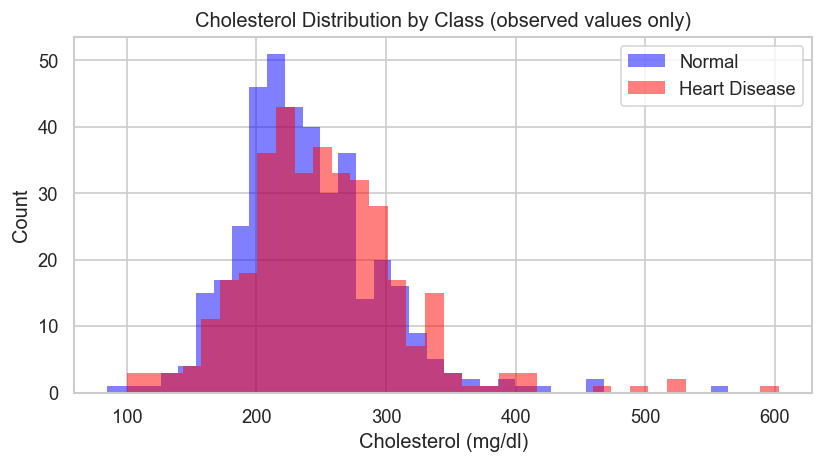

In [8]:
# Cholesterol distribution in observed rows
# The distribution determines whether mean or median is appropriate.
chol_obs = df.loc[~missing_mask, 'cholesterol']
stat_sw, p_sw = stats.shapiro(chol_obs.sample(500, random_state=42))

# Shapiro-Wilk test informs us whether cholesterol could be normally distributed
print(f'Cholesterol (observed, n={len(chol_obs)}):')
print(f'  Mean={chol_obs.mean():.1f}   Median={chol_obs.median():.1f}   '
      f'Skew={chol_obs.skew():.2f}')
print(f'  Shapiro-Wilk p={p_sw:.2e}  →  {"NOT normal" if p_sw<0.05 else "normal"}')
print()

# Class-conditional statistics
for cls, label in [(0,'Normal'), (1,'Heart Disease')]:
    c = df.loc[(df['target']==cls) & ~missing_mask, 'cholesterol']
    print(f'  {label:<14}: mean={c.mean():.1f}  median={c.median():.1f}  '
          f'n={len(c)}')

t, p_t = stats.ttest_ind(
    df.loc[(df['target']==0) & ~missing_mask, 'cholesterol'],
    df.loc[(df['target']==1) & ~missing_mask, 'cholesterol']
)
print(f'\n  t-test between classes: p={p_t:.4f}  '
      f'→  {"significant difference" if p_t<0.05 else "no significant difference"}')
print(f'  Difference in medians: '
      f'{df.loc[(df["target"]==1)&~missing_mask,"cholesterol"].median() - df.loc[(df["target"]==0)&~missing_mask,"cholesterol"].median():.1f} mg/dl')

# Histogram
fig, ax = plt.subplots(figsize=(7, 4))
for cls, label, color in [(0,'Normal','blue'),(1,'Heart Disease','red')]:
    vals = df.loc[(df['target']==cls) & ~missing_mask, 'cholesterol']
    ax.hist(vals, bins=35, alpha=0.5, color=color, label=label, edgecolor='none')
ax.set_xlabel('Cholesterol (mg/dl)')
ax.set_ylabel('Count')
ax.set_title('Cholesterol Distribution by Class (observed values only)')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
# Train/test split
# 80/20 patient-independent stratified split.
# stratify=y preserves class ratio; random_state=42 ensures reproducibility.
# All preprocessing parameters will be fitted on training data only.
FEATURES = [c for c in df.columns if c != 'target']
X = df[FEATURES]; y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_tr = X_train.reset_index(drop=True)
X_te = X_test.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)
y_te = y_test.reset_index(drop=True)

# Imputation function 
# Class-conditional median imputation for cholesterol:
#   - Missingness is MAR on class, so within-class medians correct the bias
#     that a global imputation value would introduce.
#   - Median preferred over mean: both class distributions are right-skewed
#     (skew ~1.2) with outliers up to 603 mg/dl.
#   - All parameters fitted on training data only; applied to test set
#     without refitting, preventing any leakage.
def apply_impute(X_tr, y_tr, X_te, y_te):
    """Class-conditional median imputation for cholesterol;
    training-median imputation for the single resting BP zero."""
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for cls in [0, 1]:
        fill = X_tr.loc[y_tr==cls, 'cholesterol'].median()
        X_tr.loc[(y_tr==cls) & X_tr['cholesterol'].isnull(), 'cholesterol'] = fill
        X_te.loc[(y_te==cls) & X_te['cholesterol'].isnull(), 'cholesterol'] = fill
    bp = X_tr['resting bp s'].median()
    X_tr['resting bp s'] = X_tr['resting bp s'].fillna(bp)
    X_te['resting bp s'] = X_te['resting bp s'].fillna(bp)
    return X_tr, X_te

print(f'Training set : {len(X_tr)} samples')
print(f'Test set     : {len(X_te)} samples')
print(f'Training – Normal: {(y_tr==0).sum()} | Heart Disease: {(y_tr==1).sum()}')
print(f'Test     – Normal: {(y_te==0).sum()} | Heart Disease: {(y_te==1).sum()}')


Training set : 734 samples
Test set     : 184 samples
Training – Normal: 328 | Heart Disease: 406
Test     – Normal: 82 | Heart Disease: 102


### 4c. Preprocessing decision

**Duplicates**: 272 exact duplicates removed. With 11 features including continuous measurements, the probability of two genuinely different patients sharing every value by chance is negligible so we deem these to be the same records.

**Cholesterol missingness**: Missingness is influenced by the target class. 29.9% missing in heart disease patients versus 4.9% in normal patients. Global imputation is inappropriate as it assigns a single value to rows that are overwhelmingly heart disease patients. **Class-conditional median imputation** is applied: training-set within-class medians (Normal: 234.0 mg/dl, Heart Disease: 247.0 mg/dl) correct the bias while respecting the right-skewed distribution of each class. Imputation parameters are fitted on training data only.

**Resting BP**: One zero replaced with training-set median.


---
## 5. Data Selection for Training and Testing

An **80/20 patient-independent stratified split** is used throughout. Each patient record appears in exactly one partition, preventing data leakage. `stratify=y` preserves the class ratio in both splits; `random_state=42` ensures reproducibility. All preprocessing parameters, imputation values, scaler means and variances, are fitted on the training set only and applied to the test set without refitting.


In [10]:
# Apply class-conditional median imputation
X_train_df, X_test_df = apply_impute(X_tr, y_tr, X_te, y_te)

print(f'Missing values remaining: '
      f'{X_train_df.isnull().sum().sum() + X_test_df.isnull().sum().sum()}')


Missing values remaining: 0


---
## 6. Feature Selection

Permutation importance ranks features by how much test-set AUC drops when each is randomly shuffled. The correlation heatmap provides background context on linear and inter-feature associations. No correlation > 0.5 observed between predictors


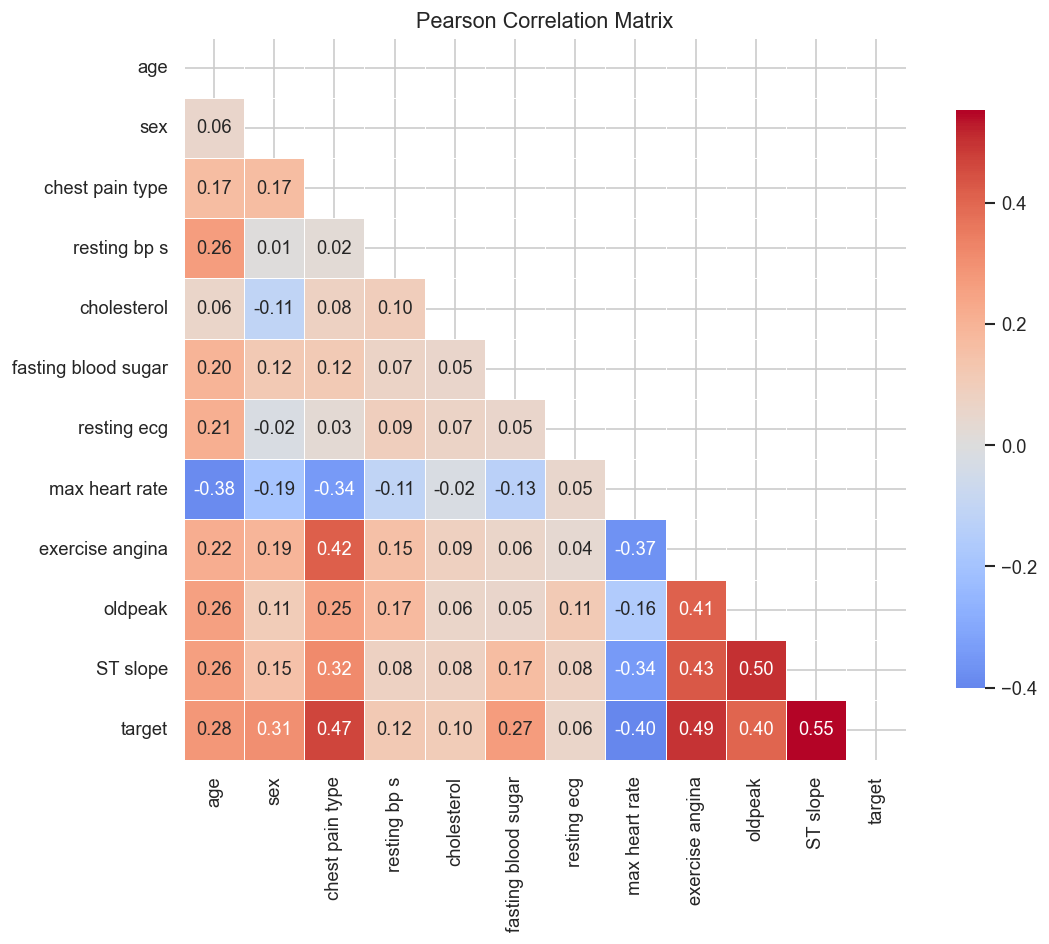

In [11]:
#  Correlation heatmap
corr = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()


Permutation importance (mean AUC drop, 30 repeats):
  ST slope                +0.0933 ± 0.0169
  chest pain type         +0.0222 ± 0.0093
  cholesterol             +0.0217 ± 0.0043
  sex                     +0.0142 ± 0.0052
  oldpeak                 +0.0124 ± 0.0072
  exercise angina         +0.0089 ± 0.0047
  resting bp s            +0.0080 ± 0.0030
  fasting blood sugar     +0.0051 ± 0.0027
  resting ecg             +0.0033 ± 0.0015
  age                     +0.0030 ± 0.0027
  max heart rate          +0.0012 ± 0.0064


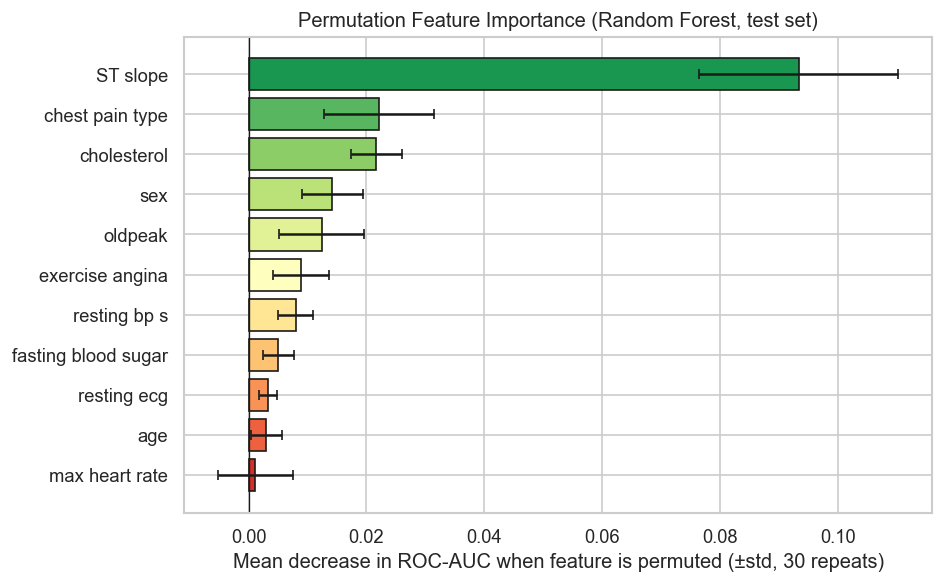

In [12]:
#  Permutation importance for feature selection 
# A Random Forest is fitted here solely to compute permutation importance
# for the feature selection decision. 
# Each feature is shuffled 30 times on the test set; the mean AUC drop
# measures how much the model relies on that feature for generalisation.
# Error bars (±1 std across 30 repeats) show stability of the estimate.
# Features whose bars cross zero do not contribute independently,
# though they may still contribute through interactions with other features.

rf_fs = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                    class_weight='balanced', random_state=42,
                                    n_jobs=-1))
])
rf_fs.fit(X_train_df, y_tr)

perm_fs = permutation_importance(
    rf_fs, X_test_df, y_te,
    n_repeats=30, scoring='roc_auc', random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({'Feature': FEATURES,
                         'Mean':    perm_fs.importances_mean,
                         'Std':     perm_fs.importances_std}
                       ).sort_values('Mean', ascending=False).reset_index(drop=True)

print('Permutation importance (mean AUC drop, 30 repeats):')
for _, row in perm_df.iterrows():
    print(f'  {row["Feature"]:<22}  {row["Mean"]:+.4f} ± {row["Std"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
perm_plot = perm_df.sort_values('Mean')
colors_p = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(FEATURES)))
ax.barh(perm_plot['Feature'], perm_plot['Mean'],
        xerr=perm_plot['Std'], color=colors_p, edgecolor='k', capsize=3)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Mean decrease in ROC-AUC when feature is permuted (±std, 30 repeats)')
ax.set_title('Permutation Feature Importance (Random Forest, test set)')
plt.tight_layout()
plt.show()


All 11 features are retained. `max heart rate` is the only feature whose permutation importance error bar crosses zero, meaning its individual contribution is not statistically distinguishable from noise. However, features can contribute through interactions without showing strong independent effects when shuffled in isolation, and cross-validated AUC does not improve reliably when any feature is removed. With no evidence for removal and all features carrying recognised clinical meaning, all 11 are kept.


---
## 7. Model Development

Three classifiers are compared. Each is wrapped in a scikit-learn **Pipeline** with `StandardScaler`, ensuring all preprocessing is fitted on training data only.

`min_samples_leaf=3` is applied to both tree-based models. This controls the minimum number of samples at a leaf node, producing shallower, more regularised trees that generalise better than the scikit-learn default of 1.


In [13]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000,    # Iterations for convergence
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,        # 200 trees for stable ensemble
            min_samples_split=5,     # Minimum samples to split a node
            min_samples_leaf=3,      # Regularisation: prevents overfitting
            class_weight='balanced', # Weights inversely proportional to class freq.
            random_state=42, n_jobs=-1 # Use all CPU cores to speed up fitting
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,    # Sequential boosting stages
            learning_rate=0.05,  # Shrinkage factor
            max_depth=4,         # Shallow trees reduce variance
            subsample=0.8,       # Stochastic boosting
            min_samples_leaf=3,
            random_state=42
        ))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

# Preliminary 5-fold CV AUC
# These are training-data estimates and will differ from test-set results
# in Section 8 due to the variance of a single 80/20 split.
print('5-Fold CV AUC (training data (estimate only); final results in Section 8)')
print('-' * 65)
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train_df, y_tr, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<24}  {scores.mean():.4f} ± {scores.std():.4f}')
print('-' * 65)


5-Fold CV AUC (training data (estimate only); final results in Section 8)
-----------------------------------------------------------------
  Logistic Regression       0.9092 ± 0.0396
  Random Forest             0.9347 ± 0.0283
  Gradient Boosting         0.9350 ± 0.0194
-----------------------------------------------------------------


In [14]:
fitted_models = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train_df, y_tr)
    fitted_models[name] = pipe
    print(f'Fitted: {name}')


Fitted: Logistic Regression
Fitted: Random Forest
Fitted: Gradient Boosting


---
## 8. Performance Metrics

| Metric | Definition | Justification |
|---|---|---|
| **Confusion Matrix** | TP, TN, FP, FN counts | Shows error types; FN (missed heart disease cases) is the most clinically critical cell |
| **Recall** | TP / (TP + FN) | Directly measures missed heart disease cases; the most dangerous error in cardiac screening |
| **F1-Score** | 2·P·R / (P+R) | Balances precision and recall; accounts for the mild class imbalance |
| **ROC-AUC** | Area under ROC curve | Threshold-independent; best for comparing models across all operating points |
| **Accuracy** | (TP+TN) / total | Overall correctness |


In [15]:
from sklearn.metrics import classification_report

results = {}
for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_test_df)
    y_prob = pipe.predict_proba(X_test_df)[:, 1]
    results[name] = {
        'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_te, y_pred),
        'f1':       f1_score(y_te, y_pred),
        'recall':   recall_score(y_te, y_pred),
        'auc':      roc_auc_score(y_te, y_prob),
        'cm':       confusion_matrix(y_te, y_pred),
        'report':   classification_report(y_te, y_pred,
                        target_names=['Normal', 'Heart Disease'])
    }
    print(f'\n{"="*52}')
    print(f'  {name}')
    print(f'{"="*52}')
    print(f'  Accuracy : {results[name]["accuracy"]:.4f}')
    print(f'  F1-Score : {results[name]["f1"]:.4f}')
    print(f'  Recall   : {results[name]["recall"]:.4f}')
    print(f'  ROC-AUC  : {results[name]["auc"]:.4f}')
    print()
    print(results[name]['report'])



  Logistic Regression
  Accuracy : 0.8641
  F1-Score : 0.8815
  Recall   : 0.9118
  ROC-AUC  : 0.9070

               precision    recall  f1-score   support

       Normal       0.88      0.80      0.84        82
Heart Disease       0.85      0.91      0.88       102

     accuracy                           0.86       184
    macro avg       0.87      0.86      0.86       184
 weighted avg       0.87      0.86      0.86       184


  Random Forest
  Accuracy : 0.9076
  F1-Score : 0.9163
  Recall   : 0.9118
  ROC-AUC  : 0.9400

               precision    recall  f1-score   support

       Normal       0.89      0.90      0.90        82
Heart Disease       0.92      0.91      0.92       102

     accuracy                           0.91       184
    macro avg       0.91      0.91      0.91       184
 weighted avg       0.91      0.91      0.91       184


  Gradient Boosting
  Accuracy : 0.9022
  F1-Score : 0.9109
  Recall   : 0.9020
  ROC-AUC  : 0.9467

               precision    re

---
## 9. Performance Analysis


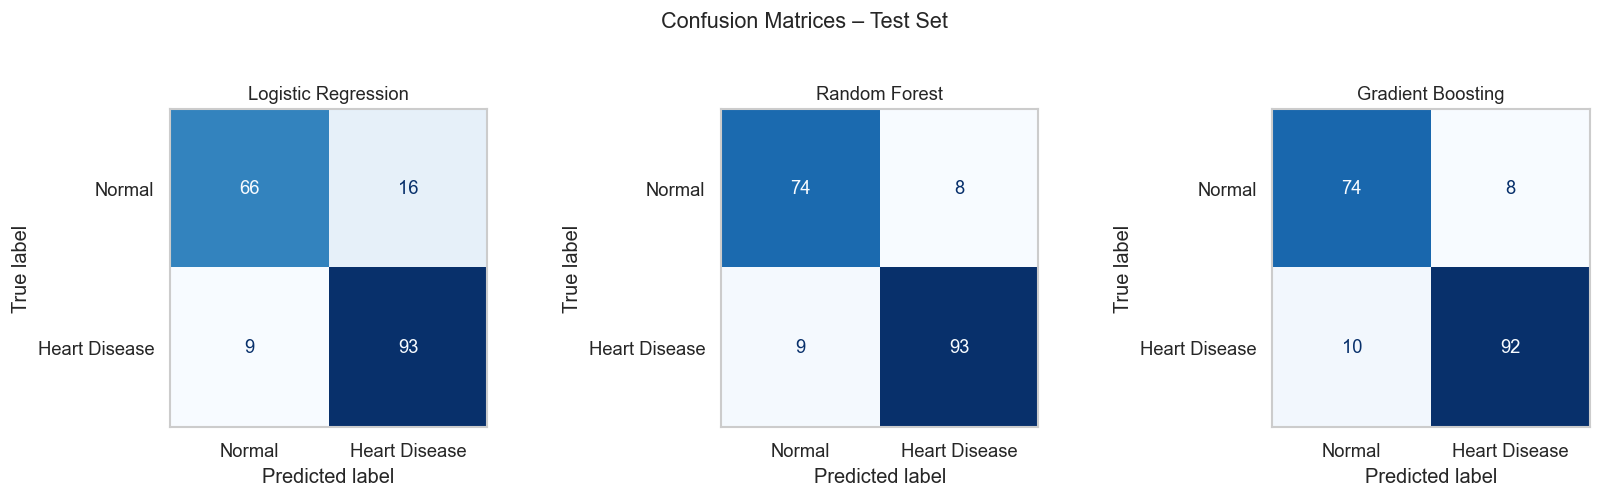

In [16]:
model_names = list(results.keys())
colors_bars = ['royalblue', 'darkorange', 'green']

# Confusion Matrices
# Absolute TP/TN/FP/FN counts for each model.
# The FN cell (bottom-left) is the most clinically important:
# these are heart disease patients predicted as healthy.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, model_names):
    ConfusionMatrixDisplay(results[name]['cm'],
                           display_labels=['Normal', 'Heart Disease']
                          ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11); ax.grid(False)
fig.suptitle('Confusion Matrices – Test Set', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


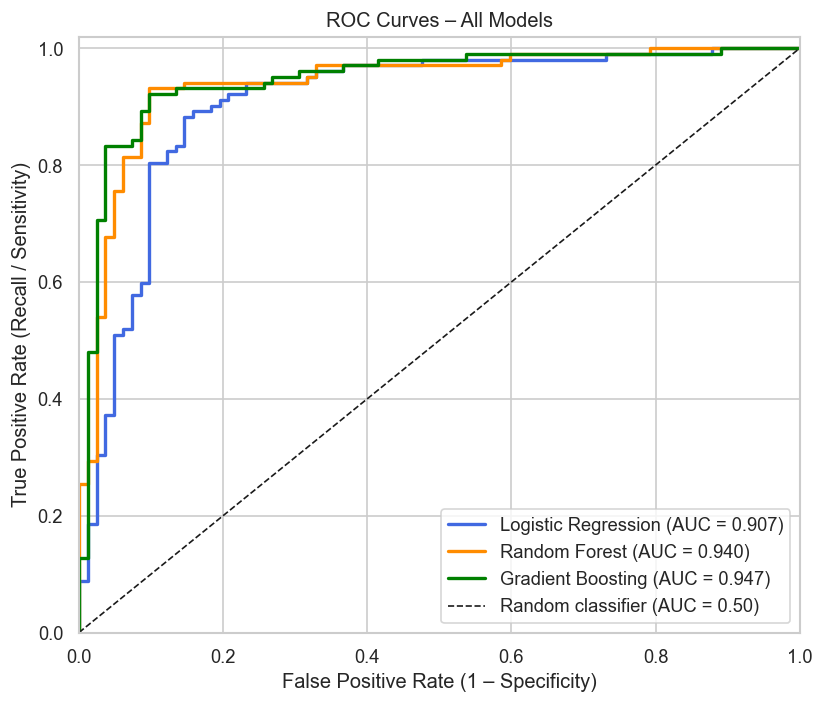

In [17]:
# ROC Curves 
# Plots True Positive Rate (recall) against False Positive Rate as the predicted-probability decision
# threshold is swept from 1 to 0. AUC = 0.5 is a random classifier;
# AUC = 1.0 is perfect separation. Closer to top-left is better.
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(model_names, colors_bars):
    fpr, tpr, _ = roc_curve(y_te, results[name]['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{name} (AUC = {results[name]["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate (1 – Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curves – All Models')
ax.legend(loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()


---
## 10. Discussion

### Model Comparison

| Model | Accuracy | F1 (HD) | Recall (HD) | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.864 | 0.882 | 0.912 | 0.907 |
| Random Forest | 0.908 | 0.916 | 0.912 | 0.940 |
| **Gradient Boosting** | 0.902 | 0.911 | 0.902 | **0.947** |

The two strongest models are closely matched, and the choice between them depends on which metric is prioritised. **Gradient Boosting achieves the highest ROC-AUC (0.947)**, reflecting the best overall separation between classes across all decision thresholds which is the most clinically meaningful property for a screening tool that may operate at different sensitivity/specificity trade-offs. **Random Forest achieves the best F1, accuracy, and recall at the default 0.5 decision threshold.** For a fixed deployment, Random Forest is marginally stronger; for a system where the threshold will be tuned to clinical requirements (e.g. maximising recall at acceptable specificity), Gradient Boosting's superior AUC is the more relevant property. Gradient Boosting is selected as the final model on these grounds.

Logistic Regression performs competitively as a linear baseline, confirming that dominant feature–target relationships are approximately linear.

### Confusion Matrix Analysis

All models show similar false negative counts; patients with heart disease predicted as healthy, the most dangerous error in a screening context. The ROC curves confirm Gradient Boosting's superior class separation across all thresholds, despite the small difference at the default operating point.

### Feature Importance

ST slope dominates permutation importance by a wide margin. Chest pain type and cholesterol follow. The moderate inter-feature correlations (~0.4 - 0.5) between ST slope, oldpeak, and exercise angina are not problematic for tree-based models and could conceivable be why these models outperform logistic regression, which is unable to exploit these interaction effects without explicit feature engineering

### Imputation

Cholesterol missingness was MAR: 29.9% missing in heart disease patients versus 4.9% in normal patients. Class-conditional median imputation was applied, using the within-class median to correct the systematic bias of global imputation, and the median is preferred over the mean because both class distributions are right-skewed with outliers (skew = 1.24, values up to 603 mg/dl).

### Limitations

- Class-conditional median imputation corrects for known MAR bias but cannot recover information that was never recorded.
- No systematic hyperparameter search was performed; grid search could improve all three models.
- Interaction effects could improve logistic regression model.


---
## 11. Conclusion

This report developed machine learning classifiers for heart disease prediction on 918 patients after removal of 272 duplicate records. Cholesterol missingness was investigated and found to be MAR, motivating class-conditional median imputation. Permutation importance and cross-validated subset comparison confirmed all 11 features should be retained.

The **Gradient Boosting Classifier** is selected as the final model on the basis of highest ROC-AUC which is the most relevant metric for a screening tool where the operating threshold may be tuned to clinical requirements:

| Metric | Value |
|---|---|
| Accuracy | 90.2% |
| F1-Score | 0.911 |
| Recall (Heart Disease) | 0.902 |
| ROC-AUC | 0.947 |

Random Forest is competitive at the default threshold (recall 0.912, AUC 0.940); if a fixed deployment threshold is required, either model is appropriate. The dominant predictors found included ST slope, chest pain type, and cholesterol.
